In [2]:
import numpy as np
from skimage import io
import matplotlib
import matplotlib.pyplot as plt
import os
from glob import glob
import torch
import torch.nn as nn
from tqdm import tqdm
from PIL import Image

from torch.utils.data import DataLoader, Dataset
from torch.autograd import Variable
if not os.path.exists('./outputs'):
    os.mkdir('./outputs')

In [34]:
# dataset preparation (Test and training)

In [19]:
import os
import shutil
from sklearn.model_selection import train_test_split

input_dir = r"E:\7711810\EuroSAT_MS"
output_dir = r"E:\7711810\EuroSAT_MS_split"
split_ratio = 0.8  # 80% train, 20% test

classes = os.listdir(input_dir)

for cls in classes:
    cls_path = os.path.join(input_dir, cls)
    if not os.path.isdir(cls_path):
        continue

    images = [f for f in os.listdir(cls_path) if f.endswith('.tif')]
    train_imgs, test_imgs = train_test_split(images, train_size=split_ratio, random_state=42)

    for phase in ['train', 'test']:
        phase_dir = os.path.join(output_dir, phase, cls)
        os.makedirs(phase_dir, exist_ok=True)

    for img in train_imgs:
        shutil.copy2(os.path.join(cls_path, img), os.path.join(output_dir, 'train', cls, img))
    for img in test_imgs:
        shutil.copy2(os.path.join(cls_path, img), os.path.join(output_dir, 'test', cls, img))

print("Multispectral dataset split completed.")


Multispectral dataset split completed.


In [39]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Input folder with class subfolders
input_dir = r"E:\7711810\EuroSAT_RGB"
output_dir = r"E:\7711810\EuroSAT_RGB_split"
split_ratio = 0.8  # 80% train, 20% test

classes = os.listdir(input_dir)

for cls in classes:
    cls_path = os.path.join(input_dir, cls)
    if not os.path.isdir(cls_path):
        continue
    
    images = [f for f in os.listdir(cls_path) if f.endswith('.jpg')]
    train_imgs, test_imgs = train_test_split(images, train_size=split_ratio, random_state=42)
    
    for phase in ['train', 'test']:
        phase_dir = os.path.join(output_dir, phase, cls)
        os.makedirs(phase_dir, exist_ok=True)
    
    for img in train_imgs:
        src = os.path.join(cls_path, img)
        dst = os.path.join(output_dir, 'train', cls, img)
        shutil.copy2(src, dst)
    
    for img in test_imgs:
        src = os.path.join(cls_path, img)
        dst = os.path.join(output_dir, 'test', cls, img)
        shutil.copy2(src, dst)

print("Dataset split completed.")


Dataset split completed.


In [20]:

# Path to your split dataset
base_path = r"E:\7711810\EuroSAT_MS_split"

# Initialize counters
train_counts = {}
test_counts = {}

# Loop through 'train' and 'test' folders
for split in ['train', 'test']:
    split_path = os.path.join(base_path, split)
    class_counts = {}

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            class_counts[class_name] = num_images

    if split == 'train':
        train_counts = class_counts
    else:
        test_counts = class_counts

# Display counts
print("Training Set:")
total_train = 0
for cls, count in train_counts.items():
    print(f"{cls}: {count}")
    total_train += count
print(f"Total Training Images: {total_train}")

print("\nTesting Set:")
total_test = 0
for cls, count in test_counts.items():
    print(f"{cls}: {count}")
    total_test += count
print(f"Total Testing Images: {total_test}")


Training Set:
AnnualCrop: 2400
Forest: 2400
HerbaceousVegetation: 2400
Highway: 2000
Industrial: 2000
Pasture: 1600
PermanentCrop: 2000
Residential: 2400
River: 2000
SeaLake: 2400
Total Training Images: 21600

Testing Set:
AnnualCrop: 600
Forest: 600
HerbaceousVegetation: 600
Highway: 500
Industrial: 500
Pasture: 400
PermanentCrop: 500
Residential: 600
River: 500
SeaLake: 600
Total Testing Images: 5400


Image shape: (64, 64, 13)
Data type: uint16
Min pixel value: 10
Max pixel value: 5350


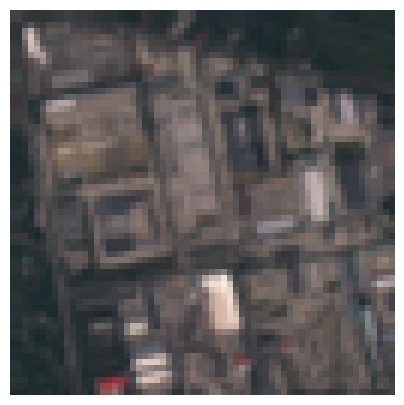

In [4]:
import tifffile as tiff

# Load the 13-band image
image_path = r"E:\7711810\EuroSAT_MS\Industrial\Industrial_67.tif"
img = tiff.imread(image_path)

print(f"Image shape: {img.shape}")  # (13, H, W) or (H, W, 13)
print(f"Data type: {img.dtype}")
print(f"Min pixel value: {np.min(img)}")
print(f"Max pixel value: {np.max(img)}")

# Rearrange shape if needed
if img.shape[0] == 13:
    img = np.transpose(img, (1, 2, 0))  # (H, W, Bands)

# Show a few representative bands (e.g., RGB-like using bands 4, 3, 2)
plt.figure(figsize=(5, 5))
rgb = img[:, :, [3, 2, 1]]  # Bands 4-3-2 (Red, Green, Blue)
plt.imshow((rgb / np.max(rgb)))
#plt.title("Bands 4-3-2 (RGB)")
plt.axis('off')
plt.show()


In [40]:
DATASET_PATH = r"E:\7711810\EuroSAT_RGB_split"

BATCH_SIZE = 64 # Number of images that are used for calculating gradients at each step

NUM_EPOCHS = 25 # Number of times we will go through all the training images. Do not go over 25

LEARNING_RATE = 0.001 # Controls the step size
MOMENTUM = 0.9 # Momentum for the gradient descent
WEIGHT_DECAY = 0.0005

In [41]:
from torchvision import datasets, models, transforms
data_transforms = transforms.Compose([
        transforms.Resize(64),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'train'), data_transforms)
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)


test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'test'), data_transforms)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes

print('Dataloaders OK')
test_loader

Dataloaders OK


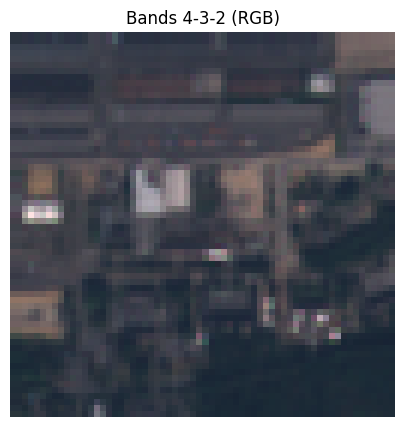

In [32]:
# Load the image
img_path = r"E:\7711810\EuroSAT_MS\Industrial\Industrial_3.tif"
image = tiff.imread(img_path)  # shape: (13, 64, 64)

# Rearrange shape if needed
if image.shape[0] == 13:
    image = np.transpose(img, (1, 2, 0))  # (H, W, Bands)

# Show a few representative bands (e.g., RGB-like using bands 4, 3, 2)
plt.figure(figsize=(5, 5))
rgb = image[:, :, [3, 2, 1]]  # Bands 4-3-2 (Red, Green, Blue)
plt.imshow((rgb / np.max(rgb)))
plt.title("Bands 4-3-2 (RGB)")
plt.axis('off')
plt.show()

In [33]:
# Creating the CNN model

In [42]:
#Create the model class
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        #Same Padding = [(filter size - 1) / 2] (Same Padding--> input size = output size)
        self.cnn1 = nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3,stride=1, padding=1)
        #The output size of each of the 4 feature maps is 
        #[(input_size - filter_size + 2(padding) / stride) +1] --> [(64-3+2(1)/1)+1] = 64 (padding type is same)
        self.batchnorm1 = nn.BatchNorm2d(4)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)
  
        #After max pooling, the output of each feature map is now 64/2 =32
        self.cnn2 = nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, stride=1, padding=1)
        #Output size of each of the 32 feature maps
        self.batchnorm2 = nn.BatchNorm2d(8)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)
        
        #After max pooling, the output of each feature map is 32/2 = 16
        #Flatten the feature maps. You have 8 feature maps, each of them is of size 16x16 --> 8*16*16 = 2048
        self.fc1 = nn.Linear(in_features=8*16*16, out_features=32)
        self.droput = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(in_features=32, out_features=10)
        
    def forward(self,x):
        out = self.cnn1(x)
        out = self.batchnorm1(out)
        out = self.relu(out)
        out = self.maxpool1(out)
        out = self.cnn2(out)
        out = self.batchnorm2(out)
        out = self.relu(out)
        out = self.maxpool2(out)
        
        #Now we have to flatten the output. This is where we apply the feed forward neural network as learned before! 
        #It will take the shape (batch_size, 2048)
        out = out.view(x.size(0), -1)
        
        #Then we forward through our fully connected layer 
        out = self.fc1(out)
        out = self.relu(out)
        #out = self.droput(out)
        out = self.fc2(out)
        return out

In [43]:
model = CNN()
if USE_CUDA:
    model = model.cuda()  
    
print('Network OK')

Network OK


In [44]:
# Define criterion, optimizer, and scheduler

criterion = nn.CrossEntropyLoss()  
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)



Running epoch 1 of 25...


Epoch 1 validation results: Loss=1.1648252373232562 | Accuracy=58.83333206176758



Running epoch 2 of 25...



C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Epoch 2 validation results: Loss=0.9852057926795061 | Accuracy=64.96295928955078



C:\Users\HP\AppData\Local\Temp\ipykernel_13040\3762102425.py:77: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(figsize=(12, 8), num=1)
C:\Users\HP\AppData\Local\Temp\ipykernel_13040\3762102425.py:88: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  plt.figure(figsize=(12, 8), num=2)




Running epoch 3 of 25...



...

C:\Users\HP\AppData\Local\Temp\ipykernel_13040\3762102425.py:77: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(figsize=(12, 8), num=1)
C:\Users\HP\AppData\Local\Temp\ipykernel_13040\3762102425.py:88: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  plt.figure(figsize=(12, 8), num=2)




Running epoch 25 of 25...



C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Epoch 25 validation results: Loss=0.5421147406101227 | Accuracy=80.72222137451172



C:\Users\HP\AppData\Local\Temp\ipykernel_13040\3762102425.py:77: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(figsize=(12, 8), num=1)
C:\Users\HP\AppData\Local\Temp\ipykernel_13040\3762102425.py:88: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  plt.figure(figsize=(12, 8), num=2)


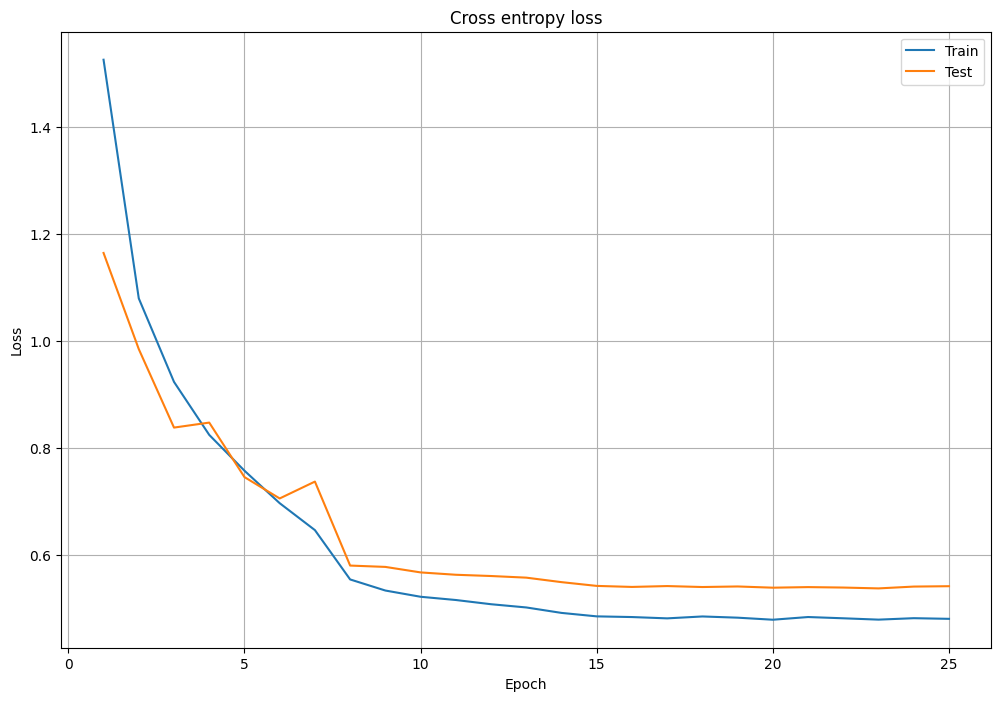

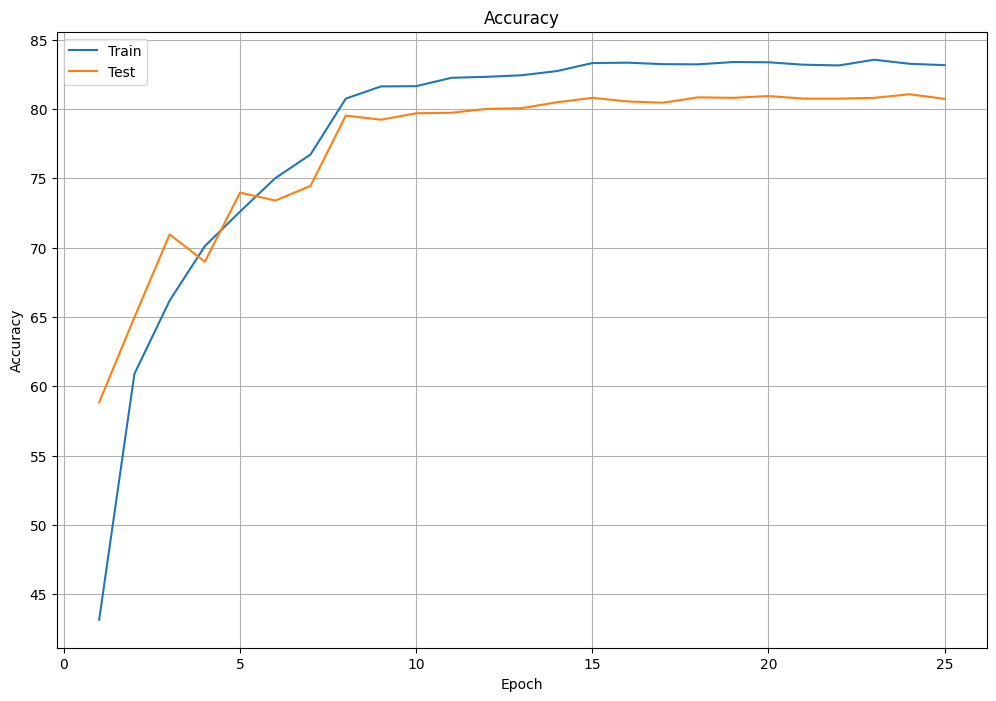

In [45]:
# Main loop
train_loss = []
train_accuracy = []
test_loss = []
test_accuracy = []
epochs = []

for epoch in range(1, NUM_EPOCHS+1):
    print(f'\n\nRunning epoch {epoch} of {NUM_EPOCHS}...\n')
    epochs.append(epoch)

    #-------------------------Train-------------------------
    
    #Reset these below variables to 0 at the begining of every epoch
    correct = 0
    iterations = 0
    iter_loss = 0.0
    
    model.train()  # Put the network into training mode
    
    for i, (inputs, labels) in enumerate(train_loader):
       
        if USE_CUDA:
            inputs = inputs.cuda()
            labels = labels.cuda()        
            
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        iter_loss += loss.item()  # Accumulate the loss
        optimizer.zero_grad() # Clear off the gradient in (w = w - gradient)
        loss.backward()   # Backpropagation 
        optimizer.step()  # Update the weights
        
        # Record the correct predictions for training data 
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum()
        iterations += 1
        
    scheduler.step()
        
    # Record the training loss
    train_loss.append(iter_loss/iterations)
    # Record the training accuracy
    train_accuracy.append((100 * correct / len(train_dataset)))   
     
    #-------------------------Test--------------------------
    
    correct = 0
    iterations = 0
    testing_loss = 0.0
    
    model.eval()  # Put the network into evaluation mode
    
    for i, (inputs, labels) in enumerate(test_loader):

        if USE_CUDA:
            inputs = inputs.cuda()
            labels = labels.cuda()
        
        outputs = model(inputs)     
        loss = criterion(outputs, labels) # Calculate the loss
        testing_loss += loss.item()
        # Record the correct predictions for training data
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum()
        
        iterations += 1

    # Record the Testing loss
    test_loss.append(testing_loss/iterations)
    # Record the Testing accuracy
    test_accuracy.append((100 * correct / len(test_dataset)))
   
    print(f'\nEpoch {epoch} validation results: Loss={test_loss[-1]} | Accuracy={test_accuracy[-1]}\n')

    # Plot and save
    plt.figure(figsize=(12, 8), num=1)
    plt.clf()
    plt.plot(epochs, train_loss, label='Train')
    plt.plot(epochs, test_loss, label='Test')
    plt.legend()
    plt.grid()
    plt.title('Cross entropy loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.savefig('outputs/01-loss-cnn.pdf')

    plt.figure(figsize=(12, 8), num=2)
    plt.clf()
    plt.plot(epochs, train_accuracy, label='Train')
    plt.plot(epochs, test_accuracy, label='Test')
    plt.legend()
    plt.grid()
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.savefig('outputs/02-accuracy-cnn.pdf')

In [61]:
print(f'Final train loss: {train_loss[-1]}')
print(f'Final test loss: {test_loss[-1]}')
print(f'Final train accuracy: {train_accuracy[-1]}')
print(f'Final test accuracy: {test_accuracy[-1]}')

Final train loss: 0.4811255851617226
Final test loss: 0.5421147406101227
Final train accuracy: 83.15277862548828
Final test accuracy: 80.72222137451172


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


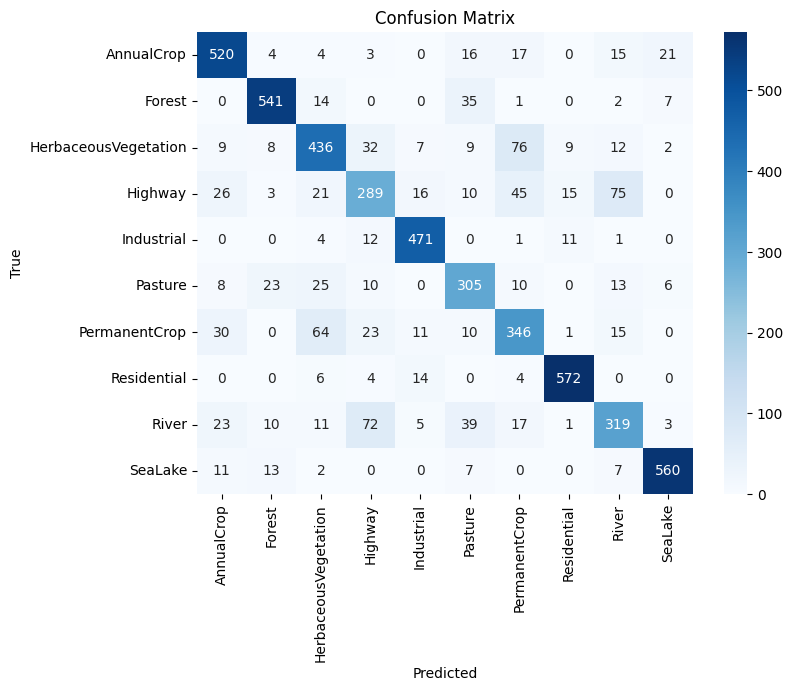

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
# Step 1: Evaluate the model on the test data and collect predictions
def get_all_preds(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

# Step 2: Generate confusion matrix
predictions, true_labels = get_all_preds(model, test_loader, device='cuda' if torch.cuda.is_available() else 'cpu')
cm = confusion_matrix(true_labels, predictions)

# Step 3: Plot it
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [56]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader, class_names, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute metrics
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')  # or 'macro'
    cm = confusion_matrix(true_labels, predictions)
    print(f"✅ Accuracy: {acc:.4f}")
    print(f"✅ F1 Score (weighted): {f1:.4f}")

In [58]:
 class_names = sorted(os.listdir('E:/7711810/EuroSAT_MS_split/test'))  # or your label list
evaluate_model(model, test_loader, class_names)


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


✅ Accuracy: 0.8072
✅ F1 Score (weighted): 0.8055


In [60]:
import torch

# Save only the model weights
torch.save(model.state_dict(), r"C:\Users\HP\SKYSERVE\CNN_classification_Model.pth")
print("Model saved to disk")


Model saved to disk
